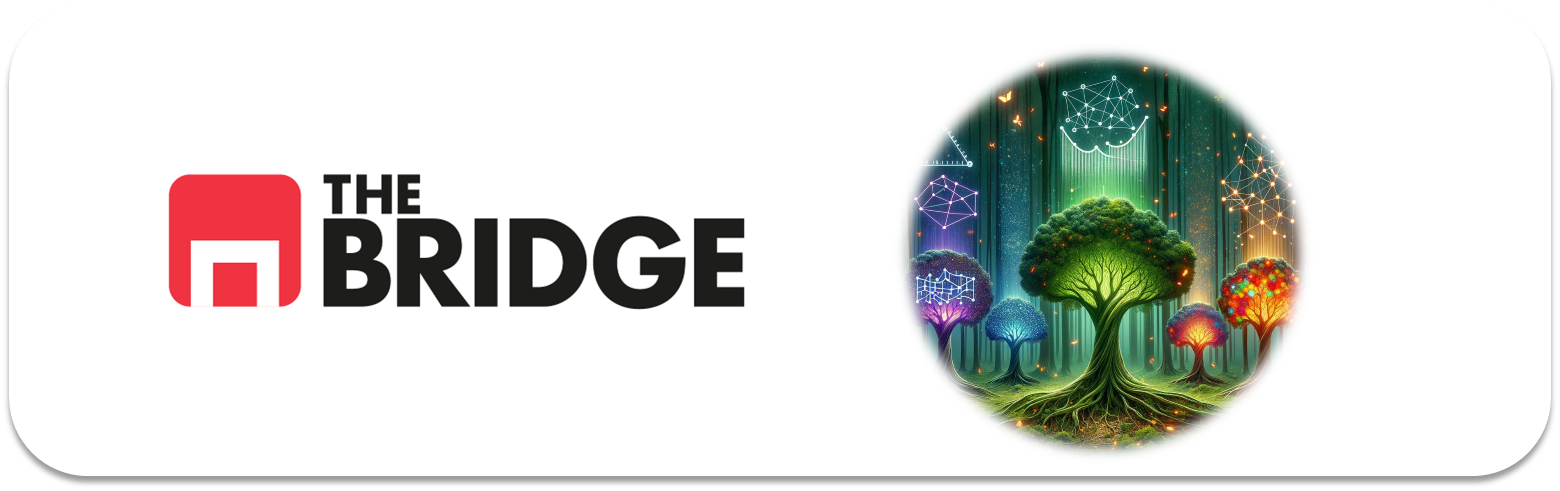

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [11]:
df = pd.read_csv("data/bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [12]:
print(df.shape)
print("\n")
print(df.info())
print("\n")
print(df.isnull().sum())

(45211, 17)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


age          0
job          0
marital      0
education    0
default      0
bal

y
no     39922
yes     5289
Name: count, dtype: int64


y
no     0.88
yes    0.12
Name: proportion, dtype: float64


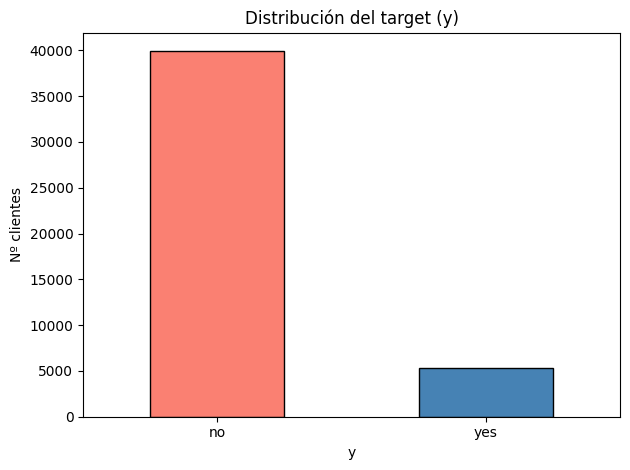

In [13]:
# Analizamos el target y
print(df["y"].value_counts())
print("\n")
print(df["y"].value_counts(normalize=True).round(2))

df["y"].value_counts().plot(kind="bar", color=["salmon", "steelblue"], edgecolor="black")
plt.title("Distribución del target (y)")
plt.xticks(rotation=0)
plt.ylabel("Nº clientes")
plt.tight_layout()
plt.show()

Como se observa, el target está muy desbalanceado: 88% vs 12%.  Un modelo que predijera siempre "no" tendría un 88% de accuracy sin aprender nada. Por eso el accuracy es completamente inútil como métrica aquí — tendremos que fijarnos especialmente en el recall y el f1-score de la clase "yes" (la minoritaria), que es la que realmente nos interesa detectar para el banco.

In [14]:
# Convertimos el target a binario (no=0, yes=1)
df["y"] = df["y"].map({"no": 0, "yes": 1})

# Split estratificado por el target para mantener la proporción 88/12
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["y"])

# Verificamos las dimensiones
print("Train:", train.shape)
print("Test:", test.shape)

# Verificamos que la proporción del target se mantiene en ambos conjuntos
print("\ny en train:")
print(train["y"].value_counts(normalize=True).round(2))
print("\ny en test:")
print(test["y"].value_counts(normalize=True).round(2))

Train: (36168, 17)
Test: (9043, 17)

y en train:
y
0    0.88
1    0.12
Name: proportion, dtype: float64

y en test:
y
0    0.88
1    0.12
Name: proportion, dtype: float64


In [15]:
# Construimos las parejas X e y de train y test
X_train = train.drop(columns=["y"])
y_train = train["y"]

X_test = test.drop(columns=["y"])
y_test = test["y"]

# Verificamos dimensiones
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (36168, 16)
X_test: (9043, 16)
y_train: (36168,)
y_test: (9043,)


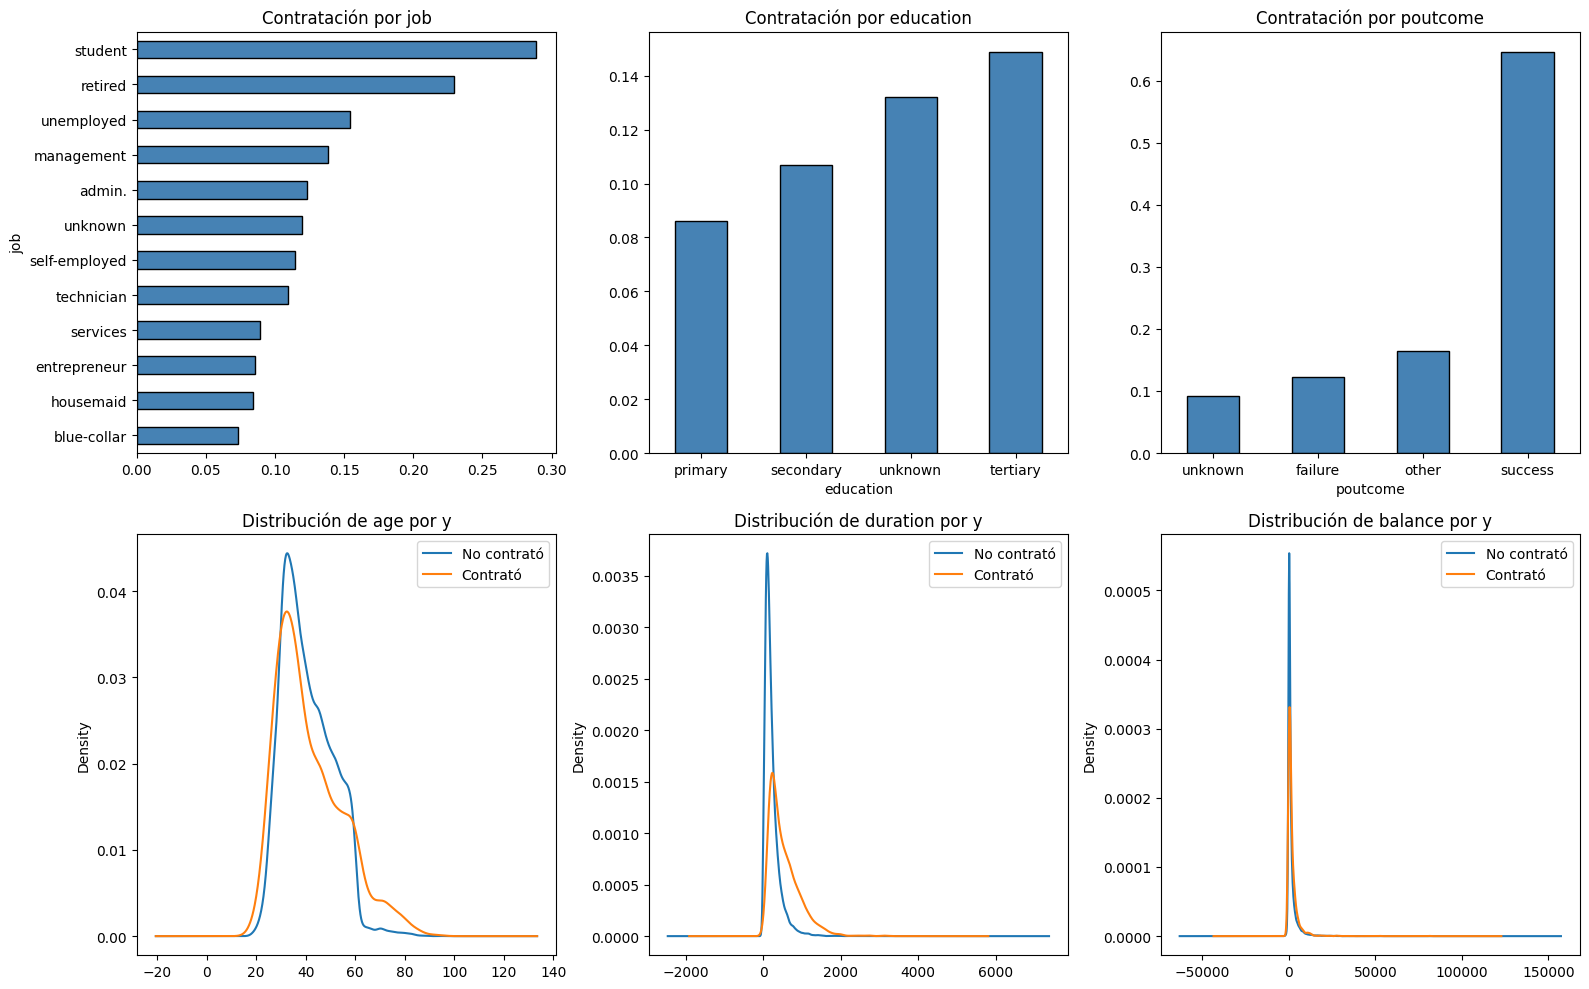

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Tasa de contratación por job
train.groupby("job")["y"].mean().sort_values().plot(kind="barh", ax=axes[0,0], color="steelblue", edgecolor="black")
axes[0,0].set_title("Contratación por job")

# Tasa de contratación por education
train.groupby("education")["y"].mean().sort_values().plot(kind="bar", ax=axes[0,1], color="steelblue", edgecolor="black")
axes[0,1].set_title("Contratación por education")
axes[0,1].tick_params(axis='x', rotation=0)

# Tasa de contratación por poutcome
train.groupby("poutcome")["y"].mean().sort_values().plot(kind="bar", ax=axes[0,2], color="steelblue", edgecolor="black")
axes[0,2].set_title("Contratación por poutcome")
axes[0,2].tick_params(axis='x', rotation=0)

# Distribución de age por y
train.groupby("y")["age"].plot(kind="kde", ax=axes[1,0], legend=True)
axes[1,0].set_title("Distribución de age por y")
axes[1,0].legend(["No contrató", "Contrató"])

# Distribución de duration por y
train.groupby("y")["duration"].plot(kind="kde", ax=axes[1,1], legend=True)
axes[1,1].set_title("Distribución de duration por y")
axes[1,1].legend(["No contrató", "Contrató"])

# Distribución de balance por y
train.groupby("y")["balance"].plot(kind="kde", ax=axes[1,2], legend=True)
axes[1,2].set_title("Distribución de balance por y")
axes[1,2].legend(["No contrató", "Contrató"])

plt.tight_layout()
plt.show()

In [17]:
# Selección de features
features = ["age", "job", "education", "balance", "duration", "campaign", "poutcome", "pdays", "previous"]

X_train = X_train[features]
X_test = X_test[features]

print(X_train.shape)
print(X_train.head())

(36168, 9)
       age         job  education  balance  duration  campaign poutcome  \
24001   36  technician  secondary      861       140         2  unknown   
43409   24     student  secondary     4126       907         4  failure   
20669   44  technician  secondary      244      1735         4  unknown   
18810   48  unemployed  secondary        0        35        11  unknown   
23130   38  technician  secondary      257        57        10  unknown   

       pdays  previous  
24001     -1         0  
43409    185         7  
20669     -1         0  
18810     -1         0  
23130     -1         0  


In [18]:
# Vemos las variables categóricas y sus valores únicos
for col in X_train.select_dtypes(include="object").columns:
    print(f"{col}: {X_train[col].unique()}")

job: ['technician' 'student' 'unemployed' 'blue-collar' 'management' 'services'
 'admin.' 'retired' 'unknown' 'entrepreneur' 'housemaid' 'self-employed']
education: ['secondary' 'tertiary' 'primary' 'unknown']
poutcome: ['unknown' 'failure' 'other' 'success']


In [19]:
# One-hot encoding de variables categóricas
X_train = pd.get_dummies(X_train, columns=["job", "education", "poutcome"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["job", "education", "poutcome"], drop_first=True)

# Verificamos el resultado
print(X_train.shape)
print(X_train.columns.tolist())

(36168, 23)
['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'education_secondary', 'education_tertiary', 'education_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


In [20]:
# Escalado de variables numéricas
cols_to_scale = ["age", "balance", "duration", "campaign", "pdays", "previous"]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(X_train.head())

            age   balance  duration  campaign     pdays  previous  \
24001 -0.460434 -0.164410 -0.457311 -0.246104 -0.410910 -0.241509   
43409 -1.589641  0.899627  2.502493  0.398202  1.446096  2.664584   
20669  0.292371 -0.365486  5.697691  0.398202 -0.410910 -0.241509   
18810  0.668773 -0.445003 -0.862499  2.653271 -0.410910 -0.241509   
23130 -0.272233 -0.361249 -0.777602  2.331118 -0.410910 -0.241509   

       job_blue-collar  job_entrepreneur  job_housemaid  job_management  ...  \
24001            False             False          False           False  ...   
43409            False             False          False           False  ...   
20669            False             False          False           False  ...   
18810            False             False          False           False  ...   
23130            False             False          False           False  ...   

       job_student  job_technician  job_unemployed  job_unknown  \
24001        False            True   

In [21]:
# Convertimos columnas booleanas a int
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

print(X_train.dtypes)

age                    float64
balance                float64
duration               float64
campaign               float64
pdays                  float64
previous               float64
job_blue-collar          int64
job_entrepreneur         int64
job_housemaid            int64
job_management           int64
job_retired              int64
job_self-employed        int64
job_services             int64
job_student              int64
job_technician           int64
job_unemployed           int64
job_unknown              int64
education_secondary      int64
education_tertiary       int64
education_unknown        int64
poutcome_other           int64
poutcome_success         int64
poutcome_unknown         int64
dtype: object


In [22]:
# Entrenamos el árbol de decisión base
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Evaluamos en train y test
y_pred_train_tree = tree.predict(X_train)
y_pred_test_tree = tree.predict(X_test)

print("=== ÁRBOL BASE - TRAIN ===")
print(classification_report(y_train, y_pred_train_tree))

print("=== ÁRBOL BASE - TEST ===")
print(classification_report(y_test, y_pred_test_tree))

=== ÁRBOL BASE - TRAIN ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31937
           1       1.00      1.00      1.00      4231

    accuracy                           1.00     36168
   macro avg       1.00      1.00      1.00     36168
weighted avg       1.00      1.00      1.00     36168

=== ÁRBOL BASE - TEST ===
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7985
           1       0.38      0.42      0.40      1058

    accuracy                           0.85      9043
   macro avg       0.65      0.66      0.66      9043
weighted avg       0.86      0.85      0.85      9043



In [23]:
# Definimos el grid de hiperparámetros a probar
param_grid = {
    "max_depth": [3, 5, 10, 15, 20],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

# Creamos el GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Entrenamos
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor f1-score en CV:", grid_search.best_score_.round(3))

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Mejor f1-score en CV: 0.482


In [24]:
# Entrenamos el árbol optimizado con los mejores hiperparámetros
best_tree = grid_search.best_estimator_

# Predicciones
y_pred_train_best = best_tree.predict(X_train)
y_pred_test_best = best_tree.predict(X_test)

print("=== ÁRBOL OPTIMIZADO - TRAIN ===")
print(classification_report(y_train, y_pred_train_best))

print("=== ÁRBOL OPTIMIZADO - TEST ===")
print(classification_report(y_test, y_pred_test_best))

=== ÁRBOL OPTIMIZADO - TRAIN ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.95     31937
           1       0.65      0.40      0.49      4231

    accuracy                           0.90     36168
   macro avg       0.79      0.69      0.72     36168
weighted avg       0.89      0.90      0.89     36168

=== ÁRBOL OPTIMIZADO - TEST ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.62      0.36      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.67      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [25]:
# Entrenamos la regresión logística con parámetros por defecto
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_test_lr = lr.predict(X_test)

print("=== REGRESIÓN LOGÍSTICA - TEST ===")
print(classification_report(y_test, y_pred_test_lr))

=== REGRESIÓN LOGÍSTICA - TEST ===
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.30      0.40      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.64      0.67      9043
weighted avg       0.88      0.90      0.88      9043



## Comparación de modelos y valoración final

| | Precision clase 1 | Recall clase 1 | F1 clase 1 | Accuracy |
|---|---|---|---|---|
| Árbol base | 0.38 | 0.42 | 0.40 | 0.85 |
| Árbol optimizado | 0.62 | 0.36 | 0.46 | 0.90 |
| Regresión logística | 0.64 | 0.30 | 0.40 | 0.90 |

El árbol optimizado es el mejor modelo overall, con el mejor f1-score para la clase 1 (0.46). 
La optimización de hiperparámetros eliminó el overfitting del árbol base y mejoró la generalización.

En un contexto bancario el recall es la métrica más crítica: es más costoso 
perder un cliente que sí contrataría que llamar a uno que no va a contratar. 
En ese sentido el árbol optimizado supera a la regresión logística (0.36 vs 0.30).

El punto débil del modelo es el bajo recall general de la clase 1, consecuencia 
del fuerte desbalance del dataset (88/12). Para mejorar esto se podría explorar 
técnicas de balanceo como SMOTE o ajustar el threshold de decisión.

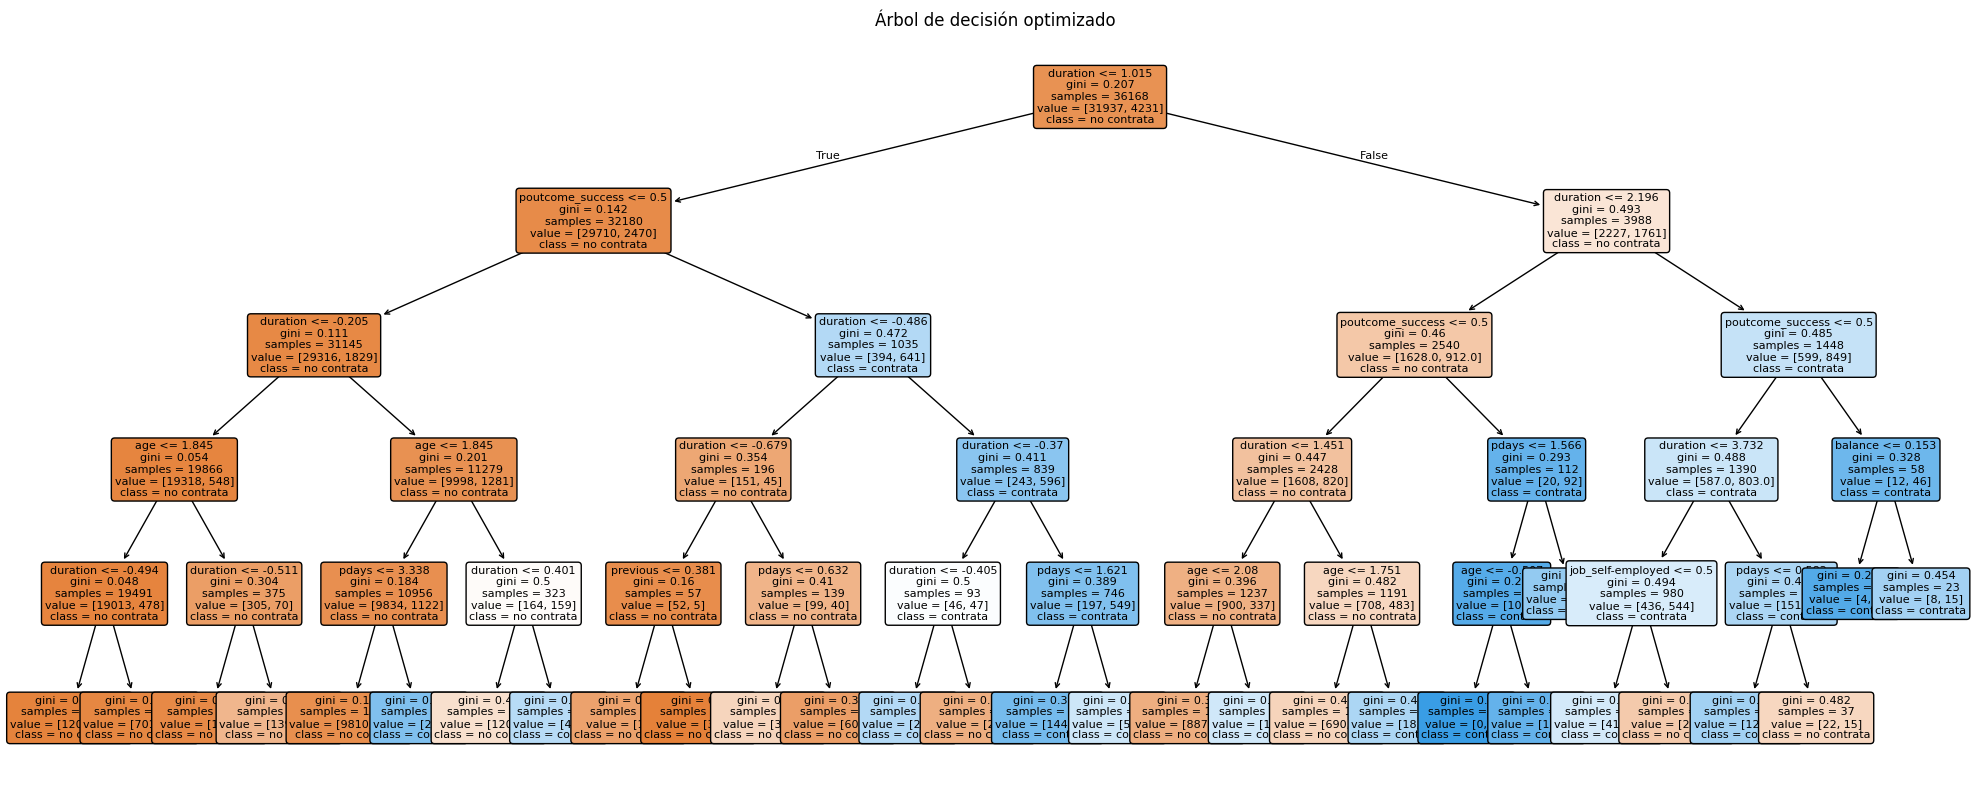

In [26]:
# Visualizamos el árbol optimizado
plt.figure(figsize=(20, 8))
plot_tree(
    best_tree,
    feature_names=X_train.columns.tolist(),
    class_names=["no contrata", "contrata"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árbol de decisión optimizado")
plt.tight_layout()
plt.show()